# 01: Data Ingestion & Exploratory Data Analysis
**Goal:** Pull historical daily data for a diversified asset universe via `yfinance`, compute returns and volatility, and look at how the assets relate to each other before any modeling starts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## Asset universe

In [2]:
TICKERS = ["SPY", "QQQ", "IWM", "EFA", "TLT", "IEF", "GLD", "DBC", "VNQ", "HYG"]
START = "2015-01-01"
END = None

raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
prices = raw["Close"].dropna(how="all")
prices.to_csv(RAW_DIR / "prices.csv")
prices.tail()

Ticker,DBC,EFA,GLD,HYG,IEF,IWM,QQQ,SPY,TLT,VNQ
Date,,,,,,,,,,
2026-08-14,30.0000,108.6400,401.4800,79.7100,93.0400,305.0900,731.0700,776.3400,82.0400,98.8300
2026-08-17,30.5600,108.4500,405.4900,79.6100,92.8400,304.0600,729.8700,772.6700,81.3500,97.9800
2026-08-18,30.4800,107.2700,398.5500,79.5300,92.9300,300.2300,717.5100,767.4500,81.6600,97.6200
2026-08-19,30.7600,107.6600,413.8400,79.7100,93.3800,301.7200,716.0800,769.0600,83.0200,98.6100
2026-08-20,31.1100,107.3500,415.2600,79.5600,93.0000,297.6700,710.9300,762.6000,82.3400,98.6000


### Log returns

In [3]:
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.to_csv(PROCESSED_DIR / "log_returns.csv")
log_returns.describe()

Ticker,DBC,EFA,GLD,HYG,IEF,IWM,QQQ,SPY,TLT,VNQ
count,"2,924.0000","2,924.0000","2,924.0000","2,924.0000","2,924.0000","2,924.0000","2,924.0000","2,924.0000","2,924.0000","2,924.0000"
mean,0.0002,0.0003,0.0004,0.0002,0.0000,0.0004,0.0007,0.0005,-0.0000,0.0002
std,0.0114,0.0109,0.0102,0.0051,0.0041,0.0141,0.0138,0.0111,0.0093,0.0129
min,-0.0828,-0.1164,-0.1084,-0.0565,-0.0254,-0.1423,-0.1276,-0.1159,-0.0690,-0.1951
25%,-0.0059,-0.0047,-0.0048,-0.0018,-0.0024,-0.0069,-0.0051,-0.0037,-0.0056,-0.0056
50%,0.0009,0.0006,0.0006,0.0002,0.0001,0.0009,0.0012,0.0006,0.0003,0.0007
75%,0.0067,0.0059,0.0056,0.0022,0.0025,0.0082,0.0078,0.0059,0.0055,0.0069
max,0.0469,0.0813,0.0616,0.0634,0.0261,0.0875,0.1134,0.0999,0.0725,0.0861


## Cumulative performance

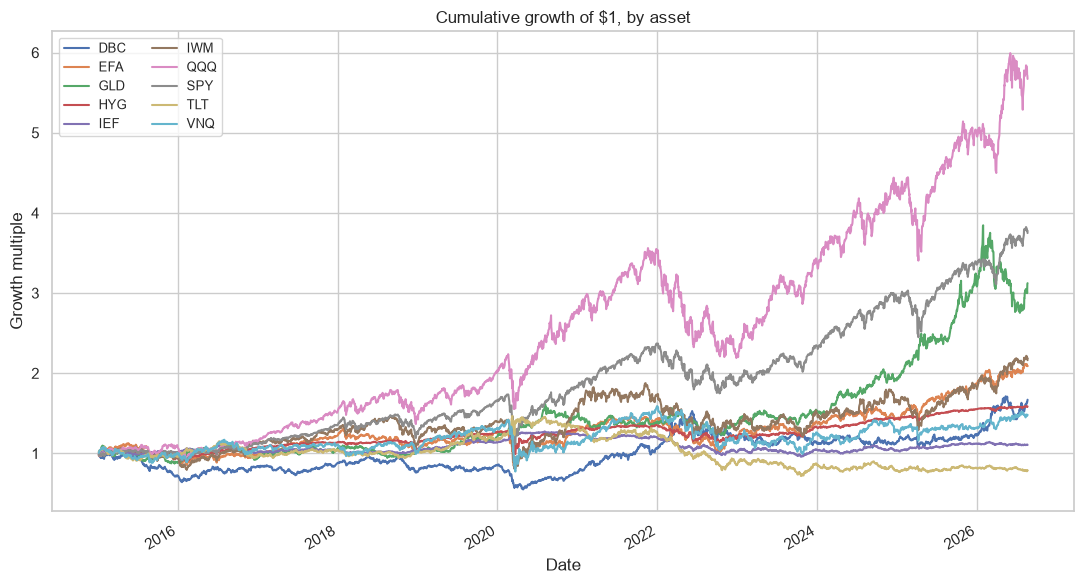

In [4]:
cum_returns = (1 + log_returns).cumprod()

fig, ax = plt.subplots(figsize=(11, 6))
cum_returns.plot(ax=ax)
ax.set_title("Cumulative growth of $1, by asset")
ax.set_ylabel("Growth multiple")
ax.legend(loc="upper left", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## Annualized return & volatility

In [5]:
ann_return = log_returns.mean() * 252
ann_vol = log_returns.std() * np.sqrt(252)

summary = pd.DataFrame({"ann_return": ann_return, "ann_vol": ann_vol})
summary["sharpe_naive"] = summary["ann_return"] / summary["ann_vol"]  # r_f = 0 for a quick look
summary.sort_values("sharpe_naive", ascending=False)

,ann_return,ann_vol,sharpe_naive
Ticker,,,
QQQ,0.1739,0.2198,0.7908
SPY,0.1295,0.1763,0.7347
GLD,0.1113,0.1621,0.6870
HYG,0.0429,0.0813,0.5281
EFA,0.0787,0.1733,0.4537
IWM,0.0918,0.2245,0.4092
DBC,0.0605,0.1805,0.3354
VNQ,0.0550,0.2040,0.2696
IEF,0.0108,0.0655,0.1650


## Covariance / correlation structure

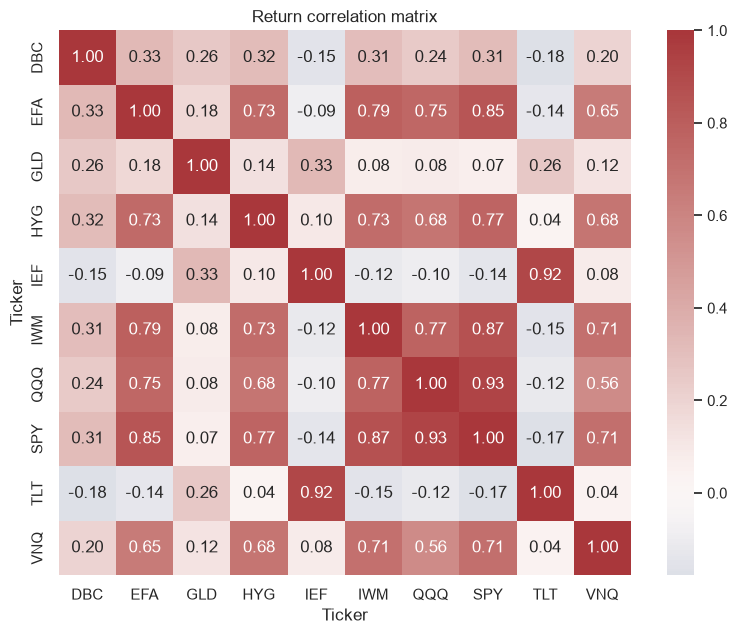

In [6]:
corr = log_returns.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Return correlation matrix")
plt.tight_layout()
plt.show()

## Rolling 60-day volatility (regime visibility)

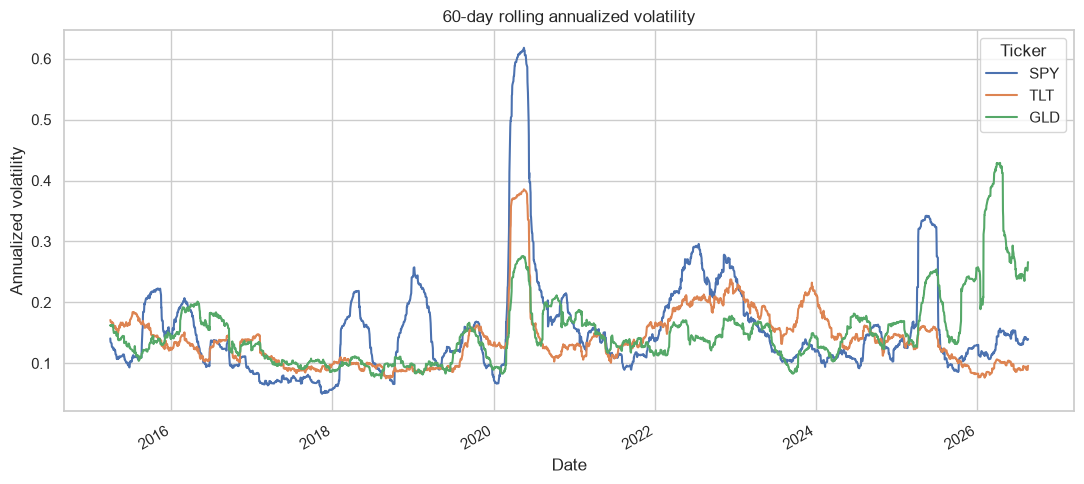

In [7]:
rolling_vol = log_returns.rolling(60).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(11, 5))
rolling_vol[["SPY", "TLT", "GLD"]].plot(ax=ax)
ax.set_title("60-day rolling annualized volatility")
ax.set_ylabel("Annualized volatility")
plt.tight_layout()
plt.show()